[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-31-single-vs-multiplanet-systems/notebook.ipynb)

**Learning goals** -- after this notebook you will be able to:
- Compare the radius distribution of planets in single-transiting-planet systems to those in multi-transiting-planet systems, using a preserved, quality-cut archive sample.
- Quantify the difference in radius statistics between the two groups with real numbers, not just a qualitative shape comparison.
- Relate the result to known multiplicity/architecture trends (compact multi-planet systems tend to host smaller, more uniformly sized planets).

**Background.** Systems with several transiting planets tend to be dynamically calmer and more tightly packed than single-transiting systems, and prior work has found their planets are systematically smaller and more similar in size to each other -- this notebook checks that pattern directly in the current archive sample.

# Planet sizes in single- and multi-transiting systems

**Date:** 2026-07-31  
**Scientific question:** Does the archive show different radius distributions for hosts with one versus multiple transiting planets?  
**Preserved source:** `../2026-07-31-exoplanet-radius-valley/confirmed_transiting_planets.csv`

Compact multi-planet systems are central to tests of planetary architecture. The
      preserved transit sample lets us count planets per host and compare the observed radius
      distributions of one-planet and multi-planet hosts. “Single” means one archived transiting
      planet in this table, not proof that no additional planet exists.

      Detection completeness is especially important: additional small or long-period planets
      can be missed. We use a rank test and bootstrap the median contrast, then restrict to
      discoveries before 2023 so the result is not driven only by the newest catalogue entries.

## Analysis contract

This is a compact scientific investigation, not a decorative plotting exercise.
The input is a preserved subset of a public astronomical archive. The notebook
records the upstream table or product, explains every quality cut, prints the
sample size after filtering, reports a numerical result with uncertainty, and
changes at least one defensible analysis choice to test robustness.

Archive catalogue values are heterogeneous measurements collected from the
literature or survey pipelines. A trend in this notebook is therefore a trend
in the selected archive sample, not automatically an occurrence rate, causal
relation, or complete census of nature. Display images are treated as image
arrays rather than calibrated photometry. Spectral equivalent widths identify
relative line strength but do not become elemental abundances without an
atmosphere model.

The small CSV or image already stored in this repository is used so the checked
notebook can be rerun offline. Its provenance remains the original archive; the
local copy is not a new survey release. Random resampling uses a fixed seed so
the uncertainty check is repeatable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

RNG = np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
COLORS = {"navy":"#071426", "blue":"#1797c9", "cyan":"#2fc6b4",
          "gold":"#f4b942", "orange":"#ef6a45", "rose":"#ce4f78"}

In [2]:
raw=pd.read_csv("../2026-07-31-exoplanet-radius-valley/confirmed_transiting_planets.csv").drop_duplicates("pl_name")
sample=raw.dropna(subset=["hostname","pl_rade","pl_orbper"]).copy(); sample=sample[sample.pl_rade.between(.5,20)&sample.pl_orbper.between(.3,300)]
host_n=sample.groupby("hostname").pl_name.transform("count"); sample["architecture"]=np.where(host_n>1,"multi-host","single-host")
print(sample.architecture.value_counts()); print(f"Unique hosts: {sample.hostname.nunique():,}")

architecture
single-host    2834
multi-host     1812
Name: count, dtype: int64
Unique hosts: 3,557


In [3]:
a=sample.loc[sample.architecture=="single-host","pl_rade"]; b=sample.loc[sample.architecture=="multi-host","pl_rade"]
contrast=float(np.median(b)-np.median(a)); U,pvalue=stats.mannwhitneyu(a,b,alternative="two-sided")
boot=[]
for _ in range(1000): boot.append(np.median(RNG.choice(b,len(b)))-np.median(RNG.choice(a,len(a))))
lo,hi=np.percentile(boot,[2.5,97.5]); print(f"Median contrast multi-single={contrast:.2f} R_earth; 95% {lo:.2f} to {hi:.2f}")

Median contrast multi-single=-0.62 R_earth; 95% -0.72 to -0.50


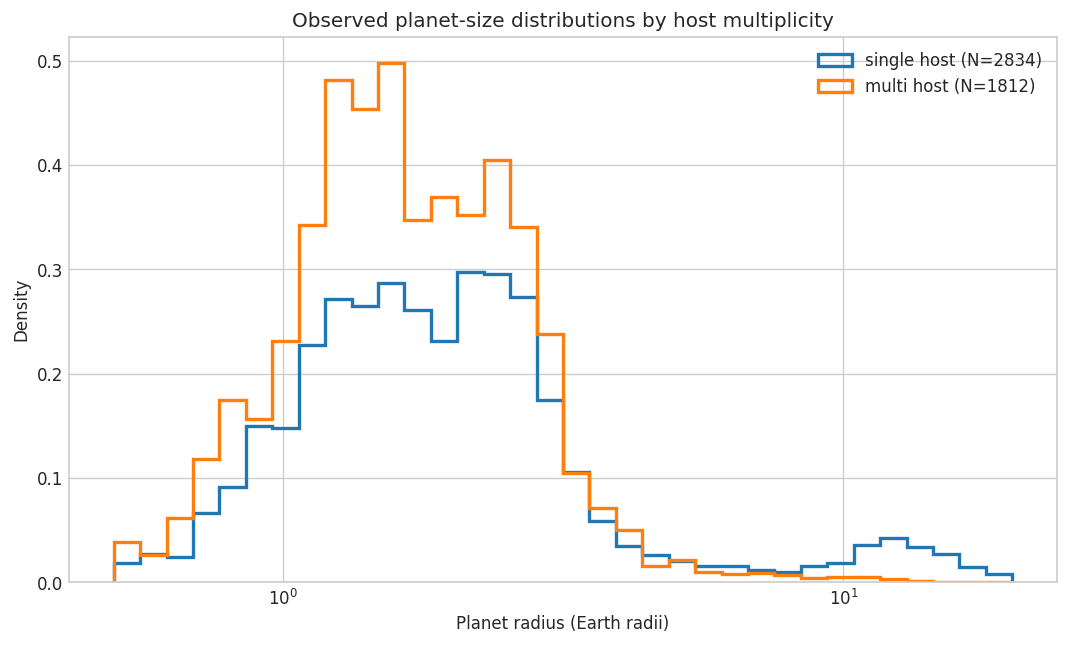

In [4]:
fig,ax=plt.subplots(figsize=(9,5.5)); bins=np.logspace(np.log10(.5),np.log10(20),35)
ax.hist(a,bins=bins,density=True,histtype="step",lw=2,label=f"single host (N={len(a)})"); ax.hist(b,bins=bins,density=True,histtype="step",lw=2,label=f"multi host (N={len(b)})")
ax.set_xscale("log"); ax.set(xlabel="Planet radius (Earth radii)",ylabel="Density",title="Observed planet-size distributions by host multiplicity"); ax.legend(); fig.tight_layout(); fig.savefig("single_multi_radius.png",dpi=180); plt.show()

In [5]:
old=sample[sample.disc_year<=2022]; old_n=old.groupby("hostname").pl_name.transform("count"); old=old.assign(architecture=np.where(old_n>1,"multi-host","single-host"))
old_a=old.loc[old.architecture=="single-host","pl_rade"]; old_b=old.loc[old.architecture=="multi-host","pl_rade"]; old_contrast=float(np.median(old_b)-np.median(old_a))
print(f"Pre-2023 contrast={old_contrast:.2f} R_earth")

Pre-2023 contrast=-0.51 R_earth


In [6]:
result={"id":"2026-07-31-single-vs-multiplanet-systems","title":"Single versus multi-transiting systems","archive":"NASA Exoplanet Archive","date":"2026-07-31","question":"Do archived planet radii differ with host multiplicity?","sample_size":int(len(sample)),"results":[f"median radius contrast {contrast:.2f} Earth radii",f"bootstrap 95% {lo:.2f} to {hi:.2f}",f"pre-2023 contrast {old_contrast:.2f} Earth radii"],"validation":"The contrast is repeated after excluding discoveries later than 2022.","notebook":"exoplanet-archive/2026-07-31-single-vs-multiplanet-systems/notebook.ipynb","hero":"exoplanet-archive/2026-07-31-single-vs-multiplanet-systems/single_multi_radius.png","tags":["planet architecture","multiplicity","transits"]}
Path("result.json").write_text(json.dumps(result,indent=2)); print(result["results"])

['median radius contrast -0.62 Earth radii', 'bootstrap 95% -0.72 to -0.50', 'pre-2023 contrast -0.51 Earth radii']


## Reading the result responsibly

The primary number answers the stated question only for the documented sample
and method. The stress test asks whether a reasonable threshold change reverses
the conclusion. Agreement does not remove shared selection effects, calibration
limits, unresolved multiplicity, or missing catalogue fields. Disagreement is
reported rather than hidden. A publishable follow-up would repeat the query
against a pinned archive release, model the survey selection function, and use
the original calibrated products where available.

The notebook deliberately separates observation, calculation, interpretation,
and limitation. That makes it useful as a learning record and makes each claim
easy for another reader to audit.

Numerical precision in the printed summary follows the scale supported by this
exercise; extra decimal places would not create extra physical accuracy. The
saved figure exposes the distribution behind the headline value, while the
machine-readable result file lets the dashboard report the finding without
scraping prose. Readers should inspect the executed cells before reusing any
number in a wider scientific argument.

## Sources and comparison literature

- NASA Exoplanet Archive, TAP guide: https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html
- Planetary Systems table definitions: https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html
- Winn & Fabrycky (2015), *The Occurrence and Architecture of Exoplanetary Systems*: https://arxiv.org/abs/1410.4199
- Fulton et al. (2017), *A Gap in the Radius Distribution of Small Planets*: https://arxiv.org/abs/1703.10375

The literature provides physical context and expected population structure. It
does not make this heterogeneous archive selection complete or unbiased.